In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath("..")
LLAVA_DIR    = os.path.join(PROJECT_ROOT, "LLaVA")
for p in [PROJECT_ROOT, LLAVA_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from llava_with_tree import load_model

MODEL_ID = "/root/autodl-tmp/Q-Vtree/checkpoints/llava-1.5-7b-hf"
# if already downloaded locally, use the path instead:
# MODEL_ID = os.path.join(PROJECT_ROOT, "checkpoints", "llava-1.5-7b-hf")

model, processor = load_model(MODEL_ID)
print("Model ready")


libgomp: Invalid value for environment variable OMP_NUM_THREADS
/root/miniconda3/envs/mllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 686/686 [00:03<00:00, 180.93it/s]


Model ready


Index        : 48
Question ID  : 48
Category     : direct_attributes
Image size   : (2250, 1500)
Question     : What is the color of the seesaw?
(A) white
(B) red
(C) black
(D) yellow
Answer with the option's letter from the given choices directly.
Ground truth : B


Text(0.5, 1.0, 'Sample 48 | What is the color of the seesaw?')

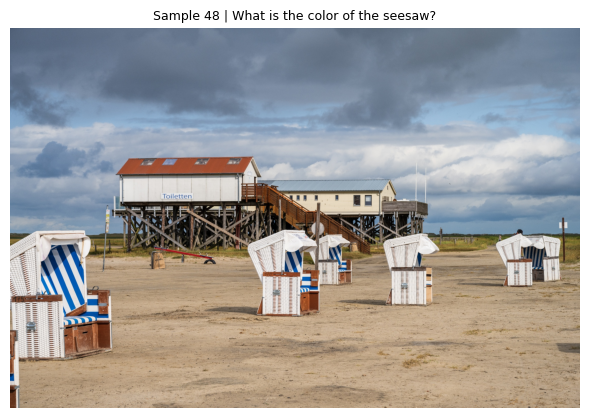

In [20]:
import json
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = os.path.join(PROJECT_ROOT, "datasets", "vstar_bench")
ANNO_FILE   = os.path.join(DATASET_DIR, "test_questions.jsonl")

with open(ANNO_FILE) as f:
    samples = [json.loads(l) for l in f]

SAMPLE_IDX = 48 # change this to pick a different sample

sample   = samples[SAMPLE_IDX]
img_path = os.path.join(DATASET_DIR, sample["image"])
image    = Image.open(img_path).convert("RGB")
question = sample["text"]
label    = sample["label"]

print(f"Index        : {SAMPLE_IDX}")
print(f"Question ID  : {sample['question_id']}")
print(f"Category     : {sample['category']}")
print(f"Image size   : {image.size}")
print(f"Question     : {question}")
print(f"Ground truth : {label}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)
ax.axis("off")
ax.set_title(question[:80], fontsize=9)
plt.tight_layout()
first_line = question.split("\n")[0]
plt.title(f"Sample {SAMPLE_IDX} | {first_line}", fontsize=9)

In [21]:
# ---- Cell 3: Baseline inference ----
from llava_with_tree import run_baseline_inference

baseline_answer = run_baseline_inference(model, processor, image, question)

print(f"Question     : {question}")
print(f"Baseline ans : {baseline_answer}")
print(f"Ground truth : {label}")

Question     : What is the color of the seesaw?
(A) white
(B) red
(C) black
(D) yellow
Answer with the option's letter from the given choices directly.
Baseline ans : A
Ground truth : B


patch_scores : shape=torch.Size([576])  min=0.0000  max=1.0000


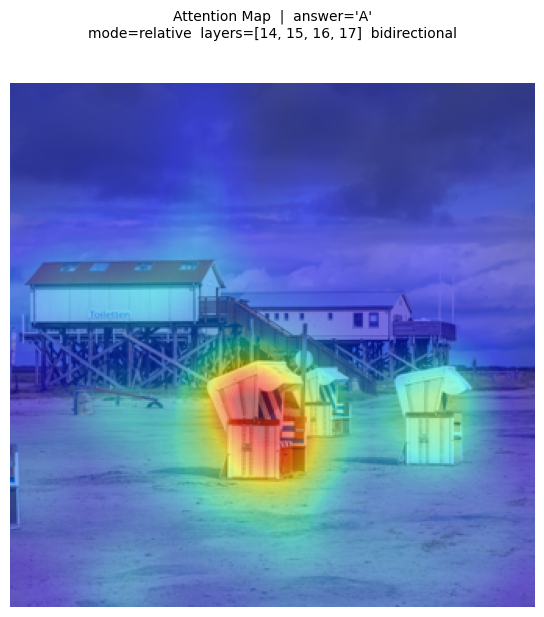

In [22]:
# ---- Cell 4: Compute patch scores (relative attention + smoothing) ----
from llava_with_tree import compute_patch_scores, recover_clip_image
from attention_viz   import visualize_attention

TARGET_LAYERS = (14, 15, 16, 17)

clip_image   = recover_clip_image(processor, image, question)
patch_scores = compute_patch_scores(
    model, processor, image, question,
    target_layers=TARGET_LAYERS,
)

print(f"patch_scores : shape={patch_scores.shape}  "
      f"min={patch_scores.min():.4f}  max={patch_scores.max():.4f}")

visualize_attention(
    image=clip_image,
    attn_result={
        "patch_scores" : patch_scores,
        "answer"       : baseline_answer,
        "use_relative" : True,
        "grid_size"    : 24,
        "target_layers": TARGET_LAYERS,
    },
    alpha=0.5,
)

Selected : 32 / 576  (5.6%)


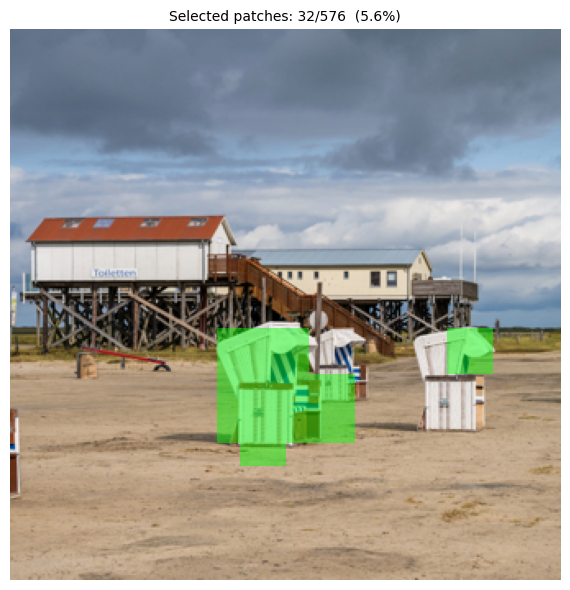

In [23]:
# ---- Cell 5: QuadTree selection -- show selected patches on image ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from llava_with_tree import select_patches, GRID_SIZE, PATCH_SIZE

SPLIT_THRESHOLD = 0.3
SOFTMAX_TEMP    = 0.2

patch_ids    = select_patches(patch_scores, SPLIT_THRESHOLD, SOFTMAX_TEMP)
num_selected = patch_ids.numel()
num_total    = GRID_SIZE * GRID_SIZE

print(f"Selected : {num_selected} / {num_total}  ({num_selected / num_total * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(clip_image)
for pid in patch_ids.tolist():
    r, c = int(pid) // GRID_SIZE, int(pid) % GRID_SIZE
    rect = mpatches.Rectangle(
        (c * PATCH_SIZE, r * PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
        linewidth=0, facecolor="lime", alpha=0.45,
    )
    ax.add_patch(rect)
ax.axis("off")
ax.set_title(
    f"Selected patches: {num_selected}/{num_total}  ({num_selected/num_total*100:.1f}%)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

Original  : (336, 336)
Compact   : (112, 84)
Merged boxes : 32


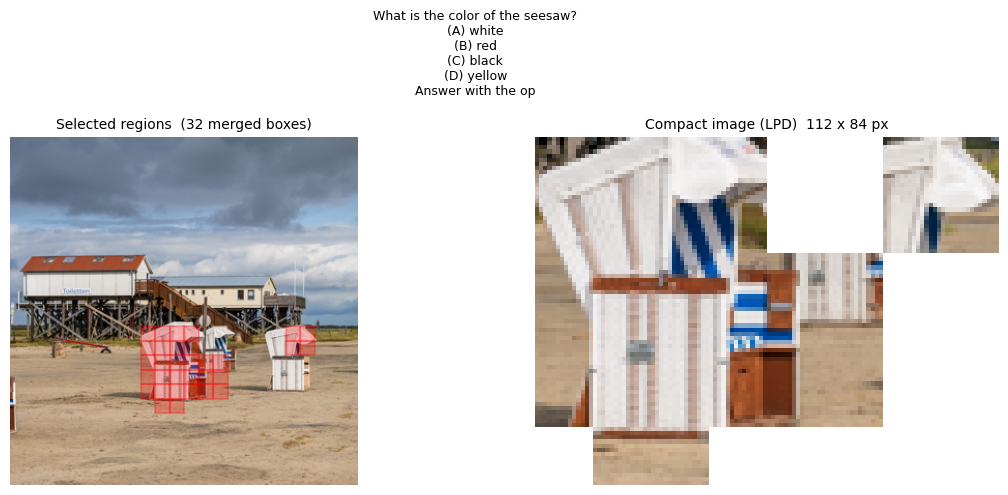

In [24]:
# ---- Cell 6: LPD -- build compact image and display ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from llava_with_tree import run_lpd

compact_image, merged_bboxes = run_lpd(patch_ids, clip_image)

print(f"Original  : {clip_image.size}")
print(f"Compact   : {compact_image.size}")
print(f"Merged boxes : {len(merged_bboxes)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(clip_image)
for (x0, y0, x1, y1) in merged_bboxes:
    rect = mpatches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=1.5, edgecolor="red", facecolor="red", alpha=0.25,
    )
    axes[0].add_patch(rect)
axes[0].axis("off")
axes[0].set_title(f"Selected regions  ({len(merged_bboxes)} merged boxes)", fontsize=10)

axes[1].imshow(compact_image)
axes[1].axis("off")
axes[1].set_title(
    f"Compact image (LPD)  {compact_image.size[0]} x {compact_image.size[1]} px",
    fontsize=10,
)

plt.suptitle(question[:90], fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# ---- Cell 7: Tree inference + final comparison ----
from llava_with_tree import run_tree_inference

tree_answer = run_tree_inference(model, processor, compact_image, question)

print("=" * 52)
print(f"  Question     : {question}")
print(f"  Ground truth : {label}")
print("-" * 52)
print(f"  Baseline     : {baseline_answer}")
print("-" * 52)
print(f"  Tree         : {tree_answer}")
print(f"  Tokens used  : {num_selected}/{num_total}  ({num_selected/num_total*100:.1f}%)")
print("=" * 52)

  Question     : What is the color of the seesaw?
(A) white
(B) red
(C) black
(D) yellow
Answer with the option's letter from the given choices directly.
  Ground truth : B
----------------------------------------------------
  Baseline     : A
----------------------------------------------------
  Tree         : A
  Tokens used  : 32/576  (5.6%)
